# Overnight vs Intraday — when does the US market earn its return?

Every trading day splits into two parts: the **overnight** move (yesterday's close -> today's open, market closed) and the **intraday** session (open -> close, market open). This notebook splits 26 years of SPY into those two components and asks three questions: **which segment earns the return, is it statistically real, and can it be traded after costs?** Then the pattern is re-checked on QQQ and IWM.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import stats
from IPython.display import display, Markdown

## 1. Data
Daily OHLC for SPY (2000-2026), auto-adjusted for dividends and splits, read from the committed CSV so the results are reproducible.

In [2]:
df = pd.read_csv(r'data\spy_raw.csv', parse_dates=['Date'], index_col='Date')

print(df.shape)
df.head()

(6669, 5)


,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,91.132751,92.895095,90.153672,92.895095,8164300
2000-01-04,87.568886,90.271146,87.500350,89.938259,8089800
2000-01-05,87.725578,88.685077,86.002397,87.686415,12177900
2000-01-06,86.315659,88.665450,86.315659,87.490554,6227200
2000-01-07,91.328621,91.328621,87.764768,87.921421,8066500


## 2. Return decomposition
- **Night** = `Open / previous Close - 1`  (the `shift(1)` uses *yesterday's* close, which avoids look-ahead bias)
- **Day** = `Close / Open - 1`
- **Whole** = full close-to-close return (the benchmark)

The two legs must **compound** into the full day: `(1+Night)(1+Day) = (1+Whole)`. Verified below (error ~1e-16 = floating-point exact).

In [3]:
df["Night"] =   df["Open"]/df["Close"].shift(1) - 1
df["Day"] = df["Close"]/df["Open"] - 1
df["Whole"] = df["Close"].pct_change()

((1+df["Night"])*(1+df["Day"])-(1+df["Whole"])).abs().max()

np.float64(2.220446049250313e-16)

Growth of \$1 in each leg, compounding daily returns with `(1+r).cumprod()`.

In [4]:
df["Night_Growth"] = (1 + df["Night"].fillna(0)).cumprod()
df["Day_Growth"] = (1 + df["Day"].fillna(0)).cumprod()
df["Whole_Growth"] = (1 + df["Whole"].fillna(0)).cumprod()

df[["Night_Growth", "Day_Growth", "Whole_Growth"]].tail(3)

,Night_Growth,Day_Growth,Whole_Growth
Date,,,
2026-07-08,6.006585,1.335885,8.179277
2026-07-09,6.022298,1.343678,8.248517
2026-07-10,6.025022,1.348860,8.284069


### Figure 1 - cumulative growth: overnight vs intraday
Log scale, so equal *percentage* moves have equal slope anywhere on the chart.

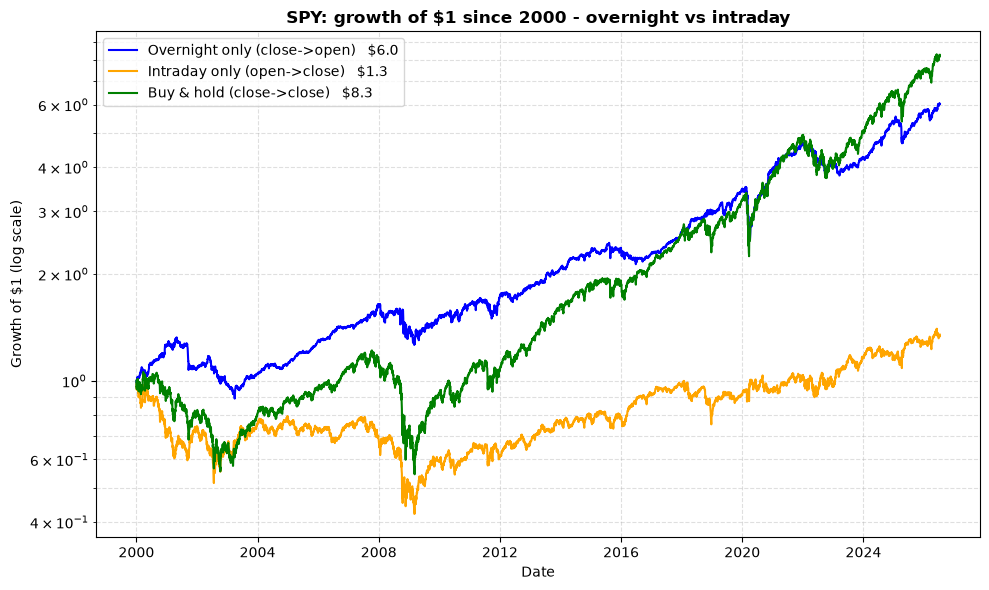

In [5]:
os.makedirs("figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df["Night_Growth"], color="blue",   label=f"Overnight only (close->open)   ${df['Night_Growth'].iloc[-1]:.1f}")
ax.plot(df["Day_Growth"],   color="orange", label=f"Intraday only (open->close)   ${df['Day_Growth'].iloc[-1]:.1f}")
ax.plot(df["Whole_Growth"], color="green",  label=f"Buy & hold (close->close)   ${df['Whole_Growth'].iloc[-1]:.1f}")

ax.set_yscale("log")
ax.set_title("SPY: growth of $1 since 2000 - overnight vs intraday", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1 (log scale)")
ax.grid(True, which="both", alpha=0.4, linestyle="--")
ax.legend()

plt.tight_layout()
plt.savefig("figures/cumulative_growth.png", bbox_inches="tight", dpi=300)
plt.show()

Almost the entire buy-and-hold return accrued **overnight**; the intraday session was nearly flat for 26 years.

## 3. Performance metrics
CAGR, annualized volatility (daily sigma x sqrt(252)), Sharpe (risk-free = 0), max drawdown, and hit rate for each leg.

In [6]:
def metrics_calulation(df, column_name):
    returns = df[column_name].fillna(0)
    years = len(df) / 252

    annual_volatility = returns.std() * np.sqrt(252)
    cagr_ratio = (1 + returns).prod() ** (1 / years) - 1
    sharpe_ratio = returns.mean()*252 / annual_volatility

    equity_curve = (1 + returns).cumprod()
    peaks = equity_curve.cummax()
    drawdown = (equity_curve / peaks) - 1
    max_dd = drawdown.min()

    hit_rate = (returns > 0).mean()

    return {
        "Years": years,
        "Annual Volatility": annual_volatility,
        "Cagr Ratio": cagr_ratio,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_dd,
        "Hit Rate": hit_rate
    }

summary_dict = {}
for col in ["Night", "Day", "Whole"]:
    summary_dict[col] = metrics_calulation(df, col)

report_df = pd.DataFrame.from_dict(summary_dict)

formatted_report = report_df.copy().astype(object)

formatted_report.loc["Years"] = report_df.loc["Years"].map("{:.1f}".format)
formatted_report.loc["Annual Volatility"] = report_df.loc["Annual Volatility"].map("{:.2%}".format)
formatted_report.loc["Cagr Ratio"] = report_df.loc["Cagr Ratio"].map("{:.2%}".format)
formatted_report.loc["Sharpe Ratio"] = report_df.loc["Sharpe Ratio"].map("{:.2f}".format)
formatted_report.loc["Max Drawdown"] = report_df.loc["Max Drawdown"].map("{:.2%}".format)
formatted_report.loc["Hit Rate"] = report_df.loc["Hit Rate"].map("{:.2%}".format)

formatted_report

,Night,Day,Whole
Years,26.5,26.5,26.5
Annual Volatility,11.20%,15.50%,19.30%
Cagr Ratio,7.02%,1.14%,8.32%
Sharpe Ratio,0.66,0.15,0.51
Max Drawdown,-32.79%,-57.04%,-55.19%
Hit Rate,55.00%,53.07%,54.49%


Overnight not only earns more - it does so at a **higher Sharpe (0.66 vs 0.51)** and **half the drawdown** (-33% vs -55%) of buy-and-hold.

## 4. Statistical tests - is it real or just luck?

### One-sample t-test: is each leg's mean daily return different from zero?

In [7]:
target_columns = ["Night", "Day", "Whole"]
table_rows = []

for col in target_columns:
    col_returns = df[col].dropna()
    t, p = stats.ttest_1samp(col_returns, popmean=0)

    table_rows.append({
        "Horizon": col,
        "Sample Mean": f"{col_returns.mean():.2%}",
        "t-statistic": f"{t:.3f}",
        "p-value": f"{p:.3f}",
        "Significant (95%)": "Yes" if p < 0.05 else "No"
    })

ttest_summary = pd.DataFrame(table_rows).set_index("Horizon")
display(ttest_summary)

,Sample Mean,t-statistic,p-value,Significant (95%)
Horizon,,,,
Night,0.03%,3.408,0.001,Yes
Day,0.01%,0.774,0.439,No
Whole,0.04%,2.626,0.009,Yes


**Night** is significant (t = 3.41 > 1.96, p = 0.001): it reliably earns more than zero. **Day** is not (t = 0.77 < 1.96, p = 0.44) - we cannot reject the null that its return is pure noise.

### Paired t-test: is Night reliably *different from* Day?

In [8]:
paired_df = df[["Night", "Day"]].dropna()

t_stat, p_val = stats.ttest_rel(paired_df["Night"], paired_df["Day"])

table_rows = []
table_rows.append({
    "Comparison": "Night vs. Day",
    "Mean Night": f"{paired_df['Night'].mean():.2%}",
    "Mean Day": f"{paired_df['Day'].mean():.2%}",
    "t-statistic": f"{t_stat:.3f}",
    "p-value": f"{p_val:.3f}",
    "Significant (95%)": "Yes" if p_val < 0.05 else "No"
})

paired_summary = pd.DataFrame(table_rows).set_index("Comparison")
display(paired_summary)

,Mean Night,Mean Day,t-statistic,p-value,Significant (95%)
Comparison,,,,,
Night vs. Day,0.03%,0.01%,1.360,0.174,No


Economically Night crushes Day, but the paired test is **not** significant (p = 0.17): the daily noise is too large to prove the difference statistically. **Economically large != statistically proven** - an important distinction to state honestly.

## 5. Transaction costs - can it actually be traded?
"Overnight only" means buy every close and sell every open: **2 trades a day, ~500 a year**. Each trade costs money (spread + commission + slippage). Below, each day's return is charged `2 x cost`. *Buy-and-hold is excluded here - it barely trades, so a daily-cost model does not apply to it.*

In [9]:
target_columns = ["Night", "Day"]
bps_list = [0, 1, 2, 5]
years = len(df) / 252

for col in target_columns:
    col_returns = df[col].fillna(0)
    table_rows = []

    for bps in bps_list:
        total_cost = 2 * (bps / 10000)
        net_daily_returns = col_returns - total_cost

        dollar_growth = (1 + net_daily_returns).prod()
        cagr_ratio = (dollar_growth) ** (1 / years) - 1

        table_rows.append({
            "Costs per Trade": f"{bps} bps",
            "$1 ->": f"${dollar_growth:.2f}",
            "CAGR": f"{cagr_ratio:+.1%}"
        })

    summary_table = pd.DataFrame(table_rows)
    display(Markdown(f"**Cost sensitivity: {col}**"))
    display(summary_table)

**Cost sensitivity: Night**

,Costs per Trade,$1 ->,CAGR
0,0 bps,$6.03,+7.0%
1,1 bps,$1.59,+1.8%
2,2 bps,$0.42,-3.2%
3,5 bps,$0.01,-16.8%


**Cost sensitivity: Day**

,Costs per Trade,$1 ->,CAGR
0,0 bps,$1.35,+1.1%
1,1 bps,$0.36,-3.8%
2,2 bps,$0.09,-8.6%
3,5 bps,$0.00,-21.4%


### Figure 2 - the overnight strategy vs transaction costs

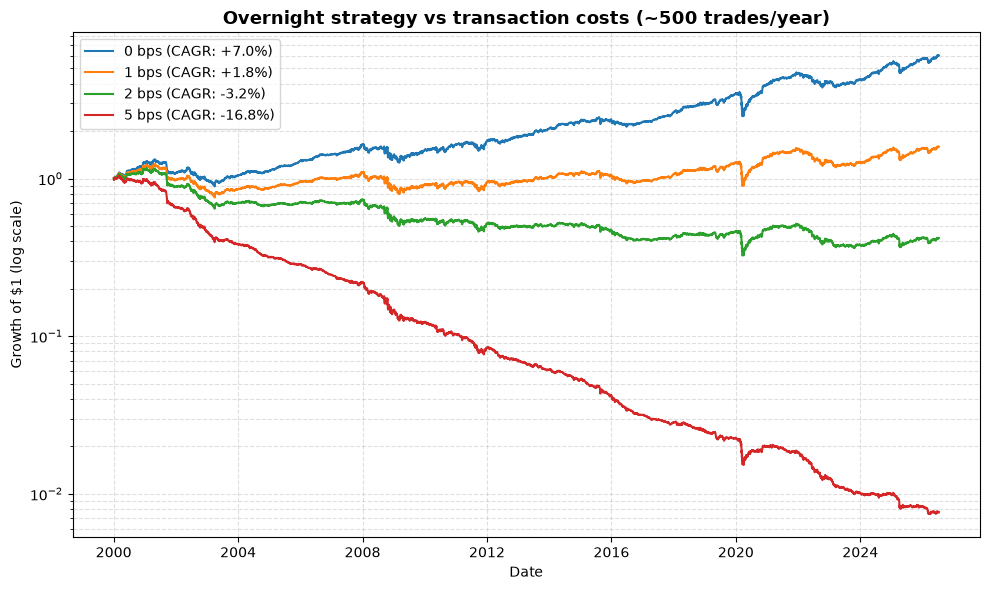

In [10]:
os.makedirs("figures", exist_ok=True)

bps_list = [0, 1, 2, 5]
total_days = len(df)
col_returns = df["Night"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))

for bps in bps_list:
    total_cost = 2 * (bps / 10000)
    net_returns = col_returns - total_cost

    equity_curve = (1 + net_returns).cumprod()
    final_val = equity_curve.iloc[-1]
    cagr = (final_val) ** (252 / total_days) - 1

    ax.plot(equity_curve, label=f"{bps} bps (CAGR: {cagr:+.1%})")

ax.set_yscale("log")
ax.set_title("Overnight strategy vs transaction costs (~500 trades/year)", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1 (log scale)")
ax.grid(True, which="both", alpha=0.4, linestyle="--")
ax.legend()

plt.tight_layout()
plt.savefig("figures/night_growth_costs.png", bbox_inches="tight", dpi=300)
plt.show()

At a realistic **2 bps/trade the overnight strategy loses money** (-3.2%/yr), even though the raw edge is +7%/yr: ~500 trades/year multiply the cost until it swamps the edge. So this is a fact about **where** return accrues, not a tradable strategy by itself.

## 6. Return by weekday
Splitting the average overnight and intraday returns by day of the week.

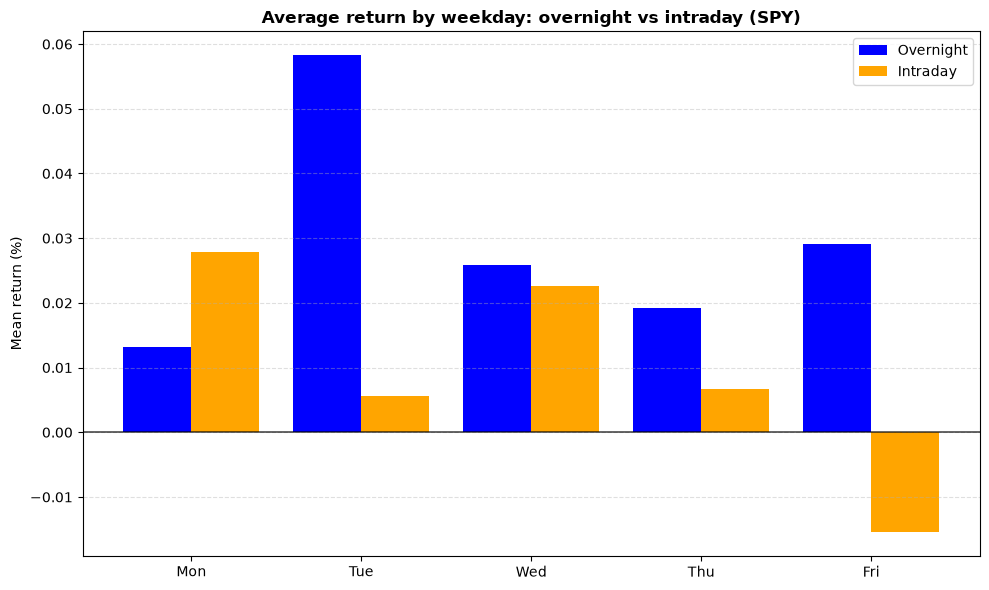

In [11]:
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
night_by_day = df["Night"].groupby(df.index.dayofweek).mean() * 100
day_by_day   = df["Day"].groupby(df.index.dayofweek).mean() * 100

x = np.arange(5)
width = 0.4

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, [night_by_day.get(i, 0) for i in range(5)], width, color="blue",   label="Overnight")
ax.bar(x + width/2, [day_by_day.get(i, 0)   for i in range(5)], width, color="orange", label="Intraday")
ax.axhline(0, color="black", linewidth=1.2, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(days)
ax.set_ylabel("Mean return (%)")
ax.set_title("Average return by weekday: overnight vs intraday (SPY)", fontweight="bold")
ax.grid(True, axis="y", alpha=0.4, linestyle="--")
ax.legend()

plt.tight_layout()
plt.savefig("figures/day_of_week.png", bbox_inches="tight", dpi=300)
plt.show()

The overnight return is positive on **every** weekday (strongest on Tuesday), while the intraday session is weakest into the weekend (negative on Friday). Per-weekday samples are small, so this is suggestive rather than conclusive.

## 7. Cross-asset check - does it hold beyond SPY?
Running the identical decomposition on **QQQ** (Nasdaq-100) and **IWM** (small caps) - data the hypothesis was not built on (an out-of-sample check).

In [12]:
def summarize_ticker(ticker):
    df_ticker = pd.read_csv(f"data/{ticker.lower()}_raw.csv", parse_dates=['Date'], index_col='Date')

    df_ticker["Night"] = df_ticker["Open"] / df_ticker["Close"].shift(1) - 1
    df_ticker["Day"]   = df_ticker["Close"] / df_ticker["Open"] - 1
    df_ticker["Whole"] = df_ticker["Close"].pct_change()

    summary_dict = {}
    for col in ["Night", "Day", "Whole"]:
        summary_dict[col] = metrics_calulation(df_ticker, col)

    report_df = pd.DataFrame.from_dict(summary_dict)
    return report_df

In [13]:
rows = []
for t in ["SPY", "QQQ", "IWM"]:
    r = summarize_ticker(t)
    rows.append({
        "Ticker": t,
        "Overnight CAGR":   r.loc["Cagr Ratio", "Night"],
        "Intraday CAGR":    r.loc["Cagr Ratio", "Day"],
        "BuyHold CAGR":     r.loc["Cagr Ratio", "Whole"],
        "Overnight Sharpe": r.loc["Sharpe Ratio", "Night"],
    })

comparison = pd.DataFrame(rows).set_index("Ticker")

display(comparison.style.format({
    "Overnight CAGR": "{:.2%}",
    "Intraday CAGR": "{:.2%}",
    "BuyHold CAGR": "{:.2%}",
    "Overnight Sharpe": "{:.2f}",
}))

,Overnight CAGR,Intraday CAGR,BuyHold CAGR,Overnight Sharpe
Ticker,,,,
SPY,7.02%,1.14%,8.32%,0.66
QQQ,11.30%,-2.39%,8.70%,0.82
IWM,13.36%,-3.98%,8.83%,1.01


### Figure 3 - CAGR by ticker: overnight vs intraday vs buy & hold

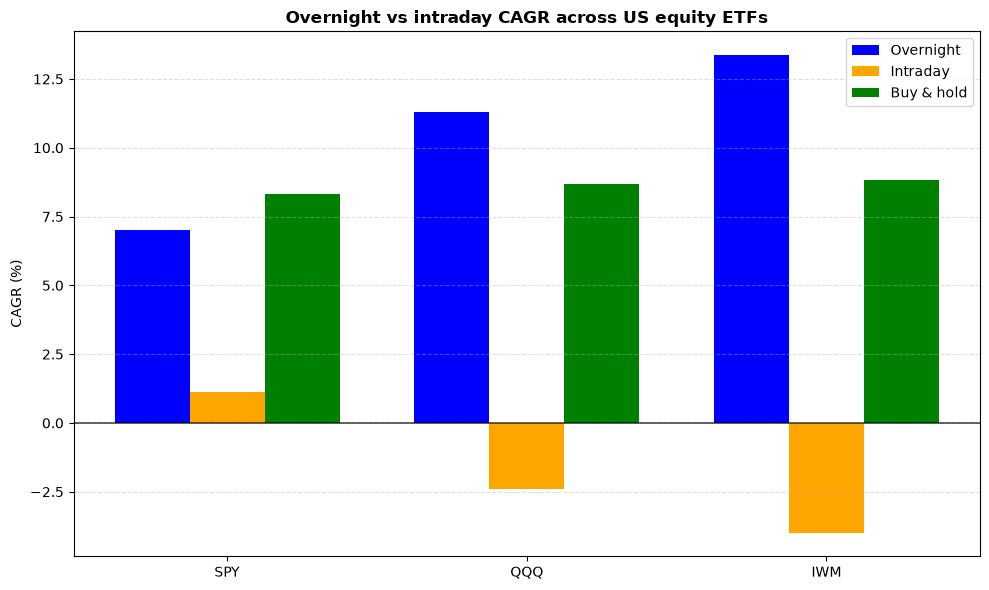

In [14]:
os.makedirs("figures", exist_ok=True)

x = np.arange(len(comparison))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, comparison["Overnight CAGR"] * 100, width, color="blue",   label="Overnight")
ax.bar(x,         comparison["Intraday CAGR"]  * 100, width, color="orange", label="Intraday")
ax.bar(x + width, comparison["BuyHold CAGR"]   * 100, width, color="green",  label="Buy & hold")
ax.axhline(0, color="black", linewidth=1.2, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(comparison.index)
ax.set_ylabel("CAGR (%)")
ax.set_title("Overnight vs intraday CAGR across US equity ETFs", fontweight="bold")
ax.grid(True, axis="y", alpha=0.4, linestyle="--")
ax.legend()

plt.tight_layout()
plt.savefig("figures/ticker_cagr_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

The effect is **stronger in higher-beta funds**: for QQQ and IWM the intraday leg is **negative** over 26 years - those ETFs made all of their return (and more) overnight, while the trading session net-destroyed value. IWM's overnight Sharpe (~1.0) is roughly double its buy-and-hold Sharpe. Holding across three independent ETFs, this looks like a structural feature of US equities, not a quirk of SPY.

## Conclusion
Since 2000, essentially the entire return of US equity indices accrued **overnight**, not during the trading session - and the effect strengthens in higher-beta funds (negative intraday for QQQ and IWM). The overnight leg is statistically significant and higher-Sharpe than buy-and-hold, but the night-vs-day difference is not statistically provable, and **~500 trades/year of costs make it unprofitable above ~1 bp/trade**. It is a real fact about market microstructure, not a turnkey strategy.

### Limitations
- yfinance's Open is the first print, not the official opening-auction price.
- Daily returns are not i.i.d. (fat tails, volatility clustering), so t-test p-values are directional, not literal.
- Costs modeled as a flat constant; the risk-free rate is set to 0 in the Sharpe ratio.
- Long-only, no leverage or taxes; ETFs only.

### How I used AI tools
I used Claude Code as a mentor - statistics explanations, code review, and independent control numbers to check my results against. I wrote and ran the analysis myself and can derive every formula in this notebook by hand.